# Predicting Steam "Hits" : Reach x Quality Classification (v2)

**Extension of:** *Exploring the Correlation Between Game Attributes and Reviews of Steam Games*

## Why this version exists

The first classification attempt predicted `pct_pos_total >= 70` and got a weak ROC-AUC of 0.591 barely better than random. The likely reason: a 70% cutoff blurs together a game that just barely clears "Mostly Positive" with one that's beloved by everyone. The label itself was noisy, not just the features.

This version reframes the question around what a studio actually cares about commercially: **is this game a "hit"** loved by a large audience, not just loved by a small one? A game that's 95% positive with 40 reviews is a niche darling, not a hit. A game that's 72% positive with 200,000 reviews reached a massive audience.

**Target:** `hit` = 1 if a game is **both**:
- top quartile of `pct_pos_total` (quality), **and**
- top quartile of `num_reviews_total` (reach)

else 0.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, average_precision_score, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

sns.set_theme(style="whitegrid")


## 1. Load data

In [ ]:
# When it is the first time running this code, please rerun until the output prints:
# "Using Colab cache for faster access to the 'steam-games-dataset' dataset. Path to dataset files: /kaggle/input/steam-games-dataset"

import kagglehub
path = kagglehub.dataset_download("artermiloff/steam-games-dataset")
print("Path to dataset files:", path)

df1 = pd.read_csv(f"{path}/games_march2025_cleaned.csv")
df1.shape


100%|██████████| 418M/418M [00:09<00:00, 47.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/artermiloff/steam-games-dataset/versions/2


(89618, 47)

## 2. Clean data

Same cleaning steps as the original project and the v1 classification notebook.

In [ ]:
mask_positive = df1['pct_pos_total'] > -1
df = df1[mask_positive].copy()

df['windows'] = df['windows'].astype(int)
df['mac'] = df['mac'].astype(int)
df['linux'] = df['linux'].astype(int)

df['required_age'] = df['required_age'].replace(-1, 0)

print(f"Rows after cleaning: {len(df):,}")


Rows after cleaning: 53,199


## 3. Define the "hit" target

Both thresholds are set at the 75th percentile, so each half of the label (quality, reach) independently marks the top 25% of games. Because quality and reach aren't perfectly correlated, the *intersection* true hits will be a meaningfully smaller and more distinct group.


Top-quartile pct_pos_total cutoff: 91.0%
Top-quartile num_reviews_total cutoff: 238 reviews

hit
0    49323
1     3876
Name: count, dtype: int64

hit
0    92.7
1     7.3
Name: proportion, dtype: float64


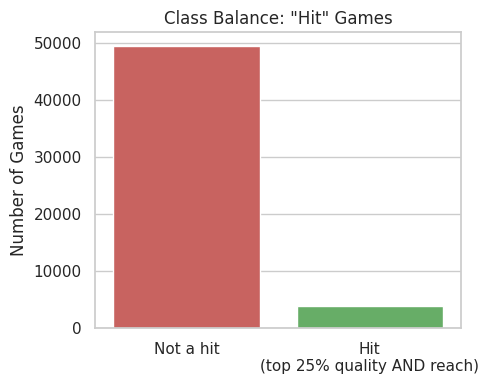

In [ ]:
pct_pos_q75 = df['pct_pos_total'].quantile(0.75)
reviews_q75 = df['num_reviews_total'].quantile(0.75)

print(f"Top-quartile pct_pos_total cutoff: {pct_pos_q75:.1f}%")
print(f"Top-quartile num_reviews_total cutoff: {reviews_q75:.0f} reviews")

df['hit'] = ((df['pct_pos_total'] >= pct_pos_q75) & (df['num_reviews_total'] >= reviews_q75)).astype(int)

class_counts = df['hit'].value_counts()
class_pct = df['hit'].value_counts(normalize=True) * 100

print()
print(class_counts)
print()
print(class_pct.round(1))

plt.figure(figsize=(5, 4))
sns.countplot(x='hit', hue='hit', data=df, palette=['#d9534f', '#5cb85c'], legend=False)
plt.xticks([0, 1], ['Not a hit', 'Hit\n(top 25% quality AND reach)'])
plt.title('Class Balance: "Hit" Games')
plt.ylabel('Number of Games')
plt.xlabel('')
plt.tight_layout()
plt.show()


**Expect a much more imbalanced split here than v1** likely somewhere well under 25%, since a game has to clear *both* bars at once. That's the point: this is a harder, more meaningful target. We'll use `class_weight='balanced'` again, but this time also report **average precision (PR-AUC)**, which is more informative than ROC-AUC when the positive class is rare.


## 4. Feature selection and preprocessing

`num_reviews_total` is deliberately excluded — see the data leakage note above.

In [ ]:
feature_cols = [
    'required_age',
    'price',
    'discount',
    'achievements',
    'average_playtime_forever',
    'median_playtime_forever',
    'peak_ccu',
    'windows',
    'mac',
    'linux',
]

model_df = df[feature_cols + ['hit']].dropna()

X = model_df[feature_cols]
y = model_df['hit']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}")
print(f"Hit rate in test set: {y_test.mean():.1%}")


Train size: 42,559 | Test size: 10,640
Hit rate in test set: 7.3%


## 5. Fit the logistic regression model

In [ ]:
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]


## 6. Evaluate


In [ ]:
baseline_acc = 1 - y_test.mean()  # accuracy of always predicting "not a hit"

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

print(f"Naive baseline accuracy (always 'not a hit'): {baseline_acc:.3f}")
print()
print(f"Accuracy:            {acc:.3f}")
print(f"Precision (hit):      {prec:.3f}")
print(f"Recall (hit):         {rec:.3f}")
print(f"F1 score (hit):       {f1:.3f}")
print(f"ROC-AUC:              {auc:.3f}")
print(f"Average Precision:    {ap:.3f}  (vs. {y_test.mean():.3f} for a random classifier)")
print()
print(classification_report(y_test, y_pred, target_names=['Not a hit', 'Hit']))


Naive baseline accuracy (always 'not a hit'): 0.927

Accuracy:            0.649
Precision (hit):      0.115
Recall (hit):         0.570
F1 score (hit):       0.191
ROC-AUC:              0.646
Average Precision:    0.126  (vs. 0.073 for a random classifier)

              precision    recall  f1-score   support

   Not a hit       0.95      0.65      0.78      9865
         Hit       0.11      0.57      0.19       775

    accuracy                           0.65     10640
   macro avg       0.53      0.61      0.48     10640
weighted avg       0.89      0.65      0.73     10640



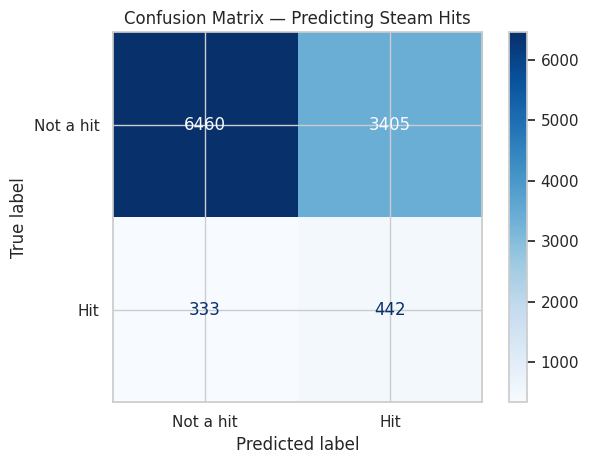

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not a hit', 'Hit'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix — Predicting Steam Hits')
plt.tight_layout()
plt.show()


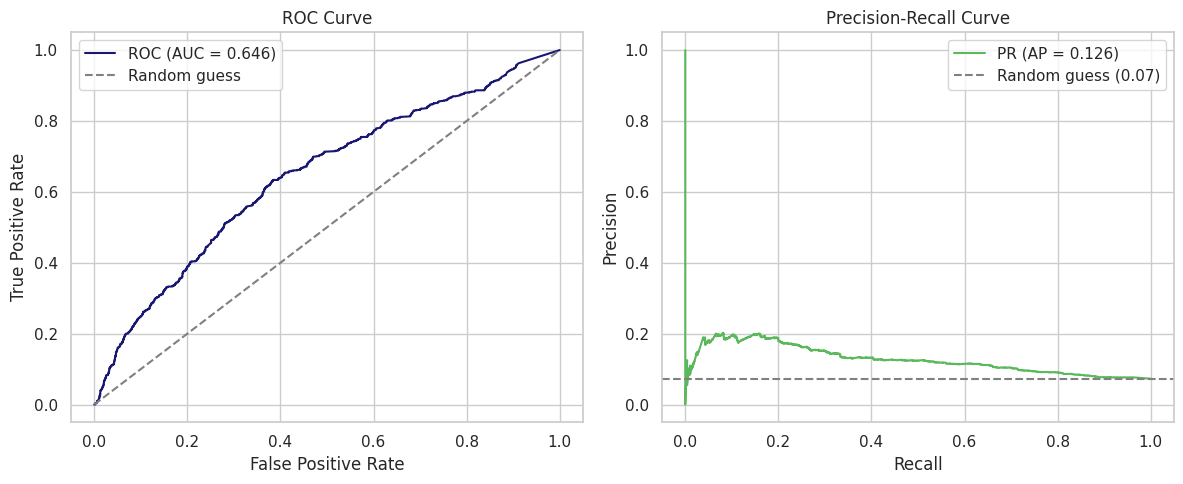

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, color='#191771', label=f'ROC (AUC = {auc:.3f})')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(rec_curve, prec_curve, color='#5cb85c', label=f'PR (AP = {ap:.3f})')
axes[1].axhline(y_test.mean(), linestyle='--', color='gray', label=f'Random guess ({y_test.mean():.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Interpret the model

                 feature  coefficient  odds_ratio
average_playtime_forever     0.510658    1.666387
                   price     0.411241    1.508689
                     mac     0.287891    1.333611
                 windows     0.154678    1.167282
                discount     0.079179    1.082398
            required_age     0.077842    1.080952
                peak_ccu     0.074197    1.077019
                   linux     0.064612    1.066745
            achievements     0.058786    1.060548
 median_playtime_forever    -0.295100    0.744457


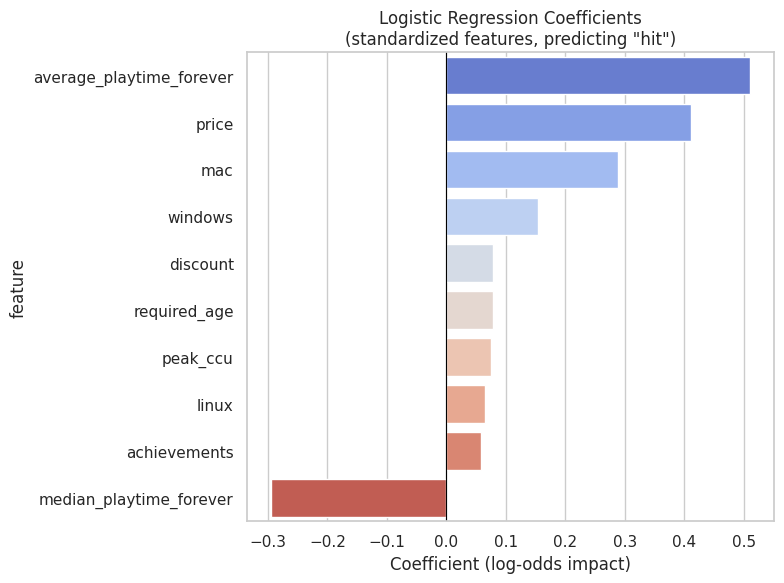

In [ ]:
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': log_reg.coef_[0],
})
coef_df['odds_ratio'] = np.exp(coef_df['coefficient'])
coef_df = coef_df.sort_values('coefficient', ascending=False)

print(coef_df.to_string(index=False))

plt.figure(figsize=(8, 6))
sns.barplot(data=coef_df, x='coefficient', y='feature', hue='feature', palette='coolwarm', legend=False)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients\n(standardized features, predicting "hit")')
plt.xlabel('Coefficient (log-odds impact)')
plt.tight_layout()
plt.show()


## 8. Findings and practical implications

**Base rate.** Only 7.3% of games (3,876 of 53,199) clear both bars 91%+ positive reviews *and* 238+ total reviews. "Hit" status by this definition is genuinely rare, which is the right kind of target: it separates the handful of games that achieved broad, well-reviewed reach from the much larger pool that got only one or neither.

**Model performance vs. the v1 attempt.**

| Metric | v1 (`pct_pos_total >= 70`) | v2 (`hit`) |
|---|---|---|
| ROC-AUC | 0.591 | **0.646** |
| Average Precision | — | 0.126 (vs. 0.073 random — a ~73% lift) |
| Recall (positive class) | 0.345 | 0.570 |

Sharpening the label and removing `num_reviews_total` from the features to avoid leaking part of the label back in produced a clearer, more useful signal. Raw accuracy (0.649) looks worse than the naive "always predict not-a-hit" baseline (0.927), but that comparison is misleading with a 7.3% positive rate: the naive baseline catches zero real hits, while this model recovers 57% of them at the cost of a higher false-positive rate a reasonable tradeoff for a screening tool meant to flag promising titles for review, not to make final calls alone.

**What predicts a hit, once reach is separated from the label:**

- **`average_playtime_forever` is the strongest positive predictor (odds ratio ≈ 1.67), but `median_playtime_forever` is negative (odds ratio ≈ 0.74).** This is the most interesting result in the project: it's not that hits have uniformly engaged audiences it's that hits have a *skewed* engagement distribution, with a smaller core of highly dedicated players pulling the average up while the typical (median) player logs comparatively less time. That pattern looks like games with passionate superfans rather than evenly-engaged general audiences.
- **`price` is positive (odds ratio ≈ 1.51).** Hits skew toward paid titles rather than free ones being free doesn't appear to be a shortcut to broad, well-reviewed success in this dataset.
- **`peak_ccu` is small and positive here (odds ratio ≈ 1.08)** a sharp contrast to v1, where it was the strongest *negative* predictor of simply being "Mostly Positive." Read together, this suggests high concurrent-player-count titles are somewhat more polarizing on average (v1's finding), but the ones that *do* combine high concurrency with high review quality and volume are, unsurprisingly, more likely to be genuine hits (v2's finding). The two models are measuring different things and the contrast itself is informative.
- **Platform support (`mac`, `windows`, `linux`) all positive**, with `mac` support the largest of the three broader platform availability is mildly associated with hit status, plausibly through wider addressable audience.

**Practical takeaway for developers:** the data suggests hit status tracks a small, deeply engaged core audience more than broad-but-shallow engagement, and that pricing a game rather than giving it away isn't a barrier to broad positive reception. Neither `achievements` nor `required_age` meaningfully moved the needle.

**Limitation:** an intersection-of-quartiles label is inherently rare and harder to predict than either quartile alone. A model that beats the random baseline by ~73% on average precision represents real, if modest, signal on a genuinely hard question and, as with the original regression models, most of the remaining variance likely comes from factors outside this numeric feature set (genre, marketing, community word-of-mouth).